# Notebook 03 — Forecasting Methods
Reproduces Figures 2, 4a, 4b, 5, 6, 7, 8 and Tables 1–2 from Hecq & Voisin (2021).

In [1]:
import sys
sys.path.append('..')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import cauchy, t as student_t

from src.preprocessing import load_data
from src.closed_form import cauchy_predictive_density, mar11_predictive_density, make_grid
from src.forecasting_sim import simulate_predictive_cdf, crash_probability
from src.forecasting_sample import sample_predictive_density, sample_crash_probability
from src.monte_carlo import simulate_mar01, find_bubble_point

params, series = load_data()
table1 = pd.read_csv('../outputs/tables/table1_simulation.csv')
table2 = pd.read_csv('../outputs/tables/table2_sample.csv')

print(f"Parameters: φ={params.phi:.3f}, ψ={params.psi:.3f}, df={params.df:.2f}")
print(f"Table 1 shape: {table1.shape}")
print(f"Table 2 shape: {table2.shape}")

Parameters : MAR(1,1) | φ=0.617062379728722, ψ=0.777070127450962, df=1.4947, σ=402.94
Series     : 475 obs [1980-02 → 2019-08]
Parameters: φ=0.617, ψ=0.777, df=1.49
Table 1 shape: (9, 6)
Table 2 shape: (36, 8)


## Figure 2 — Density evolution (Cauchy MAR(0,1), ψ=0.8)
Shows the unimodal→bimodal transition as u_T increases from Q(0.55) to Q(0.975).

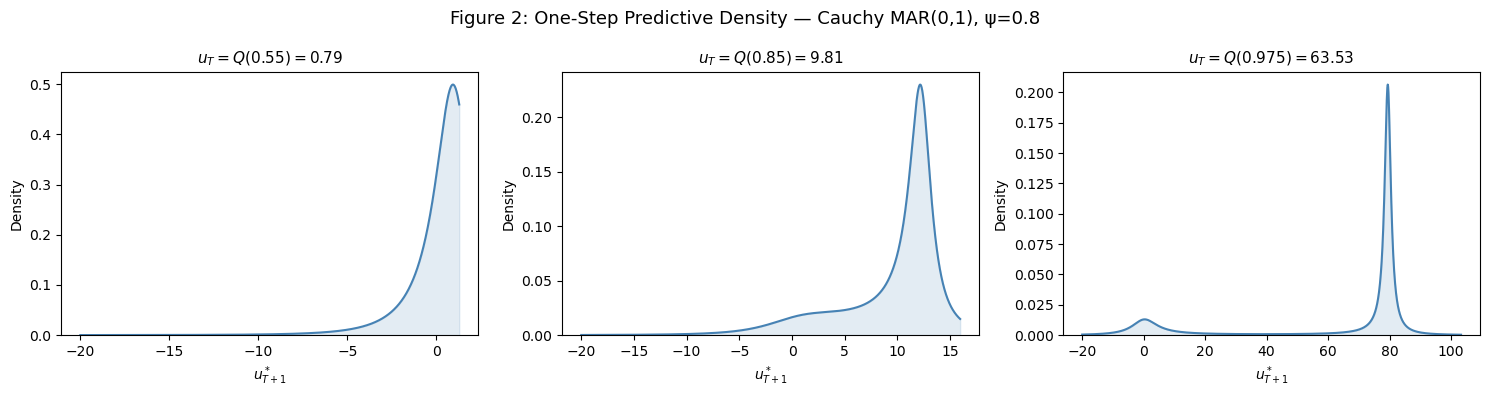

Saved fig02_density_evolution.png


In [2]:
psi, gamma = 0.8, 1.0
marginal_scale = gamma / (1 - psi)   # 5.0

quantile_levels = [0.55, 0.85, 0.975]
u_T_vals = [cauchy.ppf(q, scale=marginal_scale) for q in quantile_levels]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, q, u_T in zip(axes, quantile_levels, u_T_vals):
    lo   = min(-4 * marginal_scale, -20)
    hi   = max(u_T * 1.5, u_T / psi * 1.3)
    grid = np.linspace(lo, hi, 2000)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dens = cauchy_predictive_density(u_T, psi, gamma, grid)
    dens /= np.trapezoid(dens, grid)

    ax.plot(grid, dens, color='steelblue', lw=1.5)
    ax.fill_between(grid, dens, alpha=0.15, color='steelblue')
    ax.set_title(f"$u_T = Q({q}) = {u_T:.2f}$", fontsize=11)
    ax.set_xlabel("$u^*_{T+1}$")
    ax.set_ylabel("Density")
    ax.set_ylim(bottom=0)

plt.suptitle("Figure 2: One-Step Predictive Density — Cauchy MAR(0,1), ψ=0.8", fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig02_density_evolution.png', dpi=150)
plt.show()
print("Saved fig02_density_evolution.png")

## Figure 4a — MSE vs quantile level
MSE between simulated CDF (N=10,000) and theoretical Cauchy CDF across quantile levels Q(0.95)–Q(0.995).

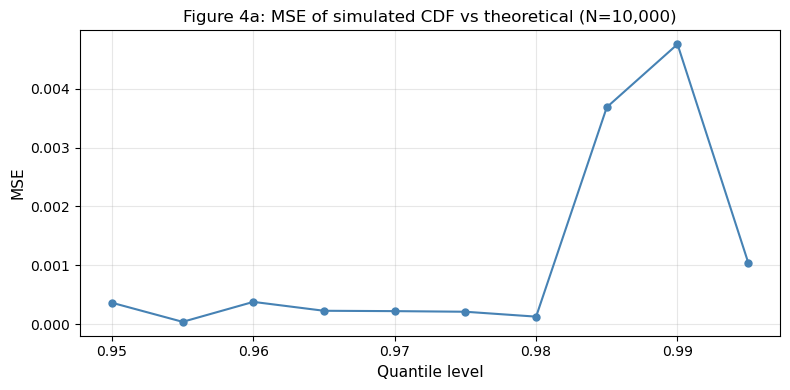

Saved fig04a_mse_vs_quantile.png


In [3]:
psi, gamma = 0.8, 1.0
N, M = 10_000, 100
quantiles = np.arange(0.950, 0.9995, 0.005)
marginal_scale = gamma / (1 - psi)

mse_vals = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for q in quantiles:
        u_T  = cauchy.ppf(q, scale=marginal_scale)
        grid = np.linspace(-50, u_T * 2.0, 500)

        dens = cauchy_predictive_density(u_T, psi, gamma, grid)
        dens /= np.trapezoid(dens, grid)
        theory_cdf = np.cumsum(dens) * (grid[1] - grid[0])

        sim_cdf = simulate_predictive_cdf(u_T, psi, 1.0, gamma, grid, N=N, M=M)
        mse_vals.append(float(np.mean((sim_cdf - theory_cdf)**2)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(quantiles, mse_vals, marker='o', ms=5, color='steelblue', lw=1.5)
ax.set_xlabel("Quantile level", fontsize=11)
ax.set_ylabel("MSE", fontsize=11)
ax.set_title(f"Figure 4a: MSE of simulated CDF vs theoretical (N={N:,})", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig04a_mse_vs_quantile.png', dpi=150)
plt.show()
print("Saved fig04a_mse_vs_quantile.png")

## Figure 4b — CDF comparison at Q(0.99)
Visual comparison of N=10,000, N=100,000 simulated CDFs against the theoretical Cauchy CDF.

u_T at Q(0.99) = 159.10
Computing N=10,000 CDF...
Computing N=100,000 CDF...
MSE N=10k: 0.000484  |  MSE N=100k: 0.000123


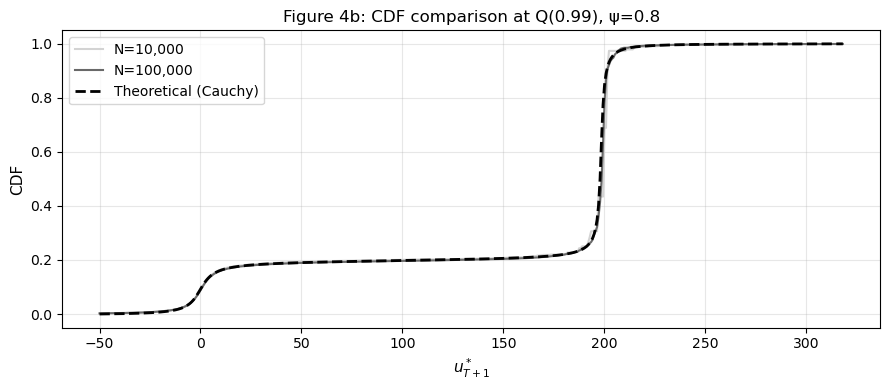

Saved fig04b_cdf_comparison.png


In [4]:
psi, gamma, M = 0.8, 1.0, 100
marginal_scale = gamma / (1 - psi)
u_T  = cauchy.ppf(0.99, scale=marginal_scale)
grid = np.linspace(-50, u_T * 2.0, 500)
print(f"u_T at Q(0.99) = {u_T:.2f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dens = cauchy_predictive_density(u_T, psi, gamma, grid)
    dens /= np.trapezoid(dens, grid)
    theory_cdf = np.cumsum(dens) * (grid[1] - grid[0])

    print("Computing N=10,000 CDF...")
    sim_cdf_10k  = simulate_predictive_cdf(u_T, psi, 1.0, gamma, grid, N=10_000,  M=M)
    print("Computing N=100,000 CDF...")
    sim_cdf_100k = simulate_predictive_cdf(u_T, psi, 1.0, gamma, grid, N=100_000, M=M)

mse_10k  = np.mean((sim_cdf_10k  - theory_cdf)**2)
mse_100k = np.mean((sim_cdf_100k - theory_cdf)**2)
print(f"MSE N=10k: {mse_10k:.6f}  |  MSE N=100k: {mse_100k:.6f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid, sim_cdf_10k,  color='lightgrey', lw=1.5, label='N=10,000')
ax.plot(grid, sim_cdf_100k, color='dimgrey',   lw=1.5, label='N=100,000')
ax.plot(grid, theory_cdf,   color='black',     lw=2,   ls='--', label='Theoretical (Cauchy)')
ax.set_xlabel("$u^*_{T+1}$", fontsize=11)
ax.set_ylabel("CDF", fontsize=11)
ax.set_title(f"Figure 4b: CDF comparison at Q(0.99), ψ={psi}", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig04b_cdf_comparison.png', dpi=150)
plt.show()
print("Saved fig04b_cdf_comparison.png")

## Figure 6 — CDF for t(2) and t(3) at Q(0.995)
Shows that bimodality is more pronounced for heavier-tailed t(2) than t(3).

t(2): u_T at Q(0.995) = 21.45
t(3): u_T at Q(0.995) = 8.15


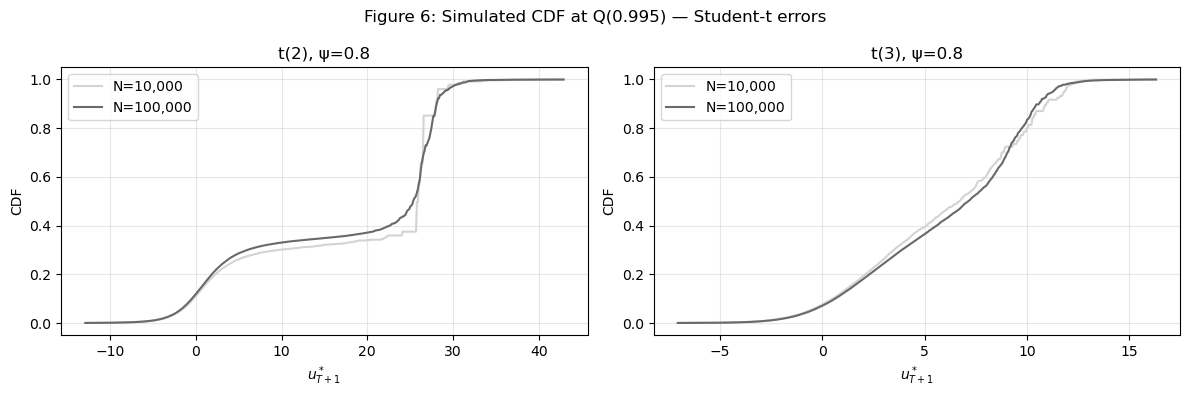

Saved fig06_student_cdf.png


In [5]:
psi, M = 0.8, 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for ax, df in zip(axes, [2, 3]):
        np.random.seed(42)
        sim  = simulate_mar01(T=10_000, psi=psi, df=float(df), scale=1.0)
        u_T  = float(np.quantile(sim, 0.995))
        grid = np.linspace(float(np.quantile(sim, 0.01)), u_T * 2, 500)
        print(f"t({df}): u_T at Q(0.995) = {u_T:.2f}")

        cdf_10k  = simulate_predictive_cdf(u_T, psi, float(df), 1.0, grid, N=10_000,  M=M)
        cdf_100k = simulate_predictive_cdf(u_T, psi, float(df), 1.0, grid, N=100_000, M=M)

        ax.plot(grid, cdf_10k,  color='lightgrey', lw=1.5, label='N=10,000')
        ax.plot(grid, cdf_100k, color='dimgrey',   lw=1.5, label='N=100,000')
        ax.set_title(f"t({df}), ψ={psi}", fontsize=12)
        ax.set_xlabel("$u^*_{{T+1}}$"); ax.set_ylabel("CDF")
        ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle("Figure 6: Simulated CDF at Q(0.995) — Student-t errors", fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig06_student_cdf.png', dpi=150)
plt.show()
print("Saved fig06_student_cdf.png")

## Table 1 — Method 1: Simulation-based crash probabilities
Reproduces Table 1 of Hecq & Voisin (2021). Theoretical values computed via closed-form Cauchy CDF at Q(0.995) with 25% crash threshold.

In [6]:
def cauchy_theoretical(psi_val, crash_quantile=0.995, crash_pct=0.25):
    """Closed-form crash probability for Cauchy MAR(0,1)."""
    marginal_scale = 1.0 / (1 - psi_val)
    u_T  = cauchy.ppf(crash_quantile, scale=marginal_scale)
    hi   = max(u_T * 2.5, (u_T / psi_val) * 1.5)
    grid = np.linspace(-500, hi, 5000)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dens = cauchy_predictive_density(u_T, psi_val, 1.0, grid)
        dens /= np.trapezoid(dens, grid)
        cdf  = np.cumsum(dens) * (grid[1] - grid[0])
    mask = grid <= (1 - crash_pct) * u_T
    return float(cdf[mask].max()) if mask.any() else np.nan

theory = {psi: cauchy_theoretical(psi) for psi in [0.2, 0.5, 0.8]}

pivot = table1.pivot_table(index='psi', columns='df', values='mean_prob').round(3)
pivot.columns = [f"t({int(c)}) sim" for c in pivot.columns]
pivot.insert(0, 'Cauchy (theory)', [theory[p] for p in pivot.index])
pivot['Cauchy (theory)'] = pivot['Cauchy (theory)'].round(3)

print("Table 1 — Method 1: Simulation-based crash probabilities")
print("(Q=0.995 bubble threshold, 25% crash, n_reps=200)")
print()
print(pivot.to_string())
print()
print("Paper reference (ψ=0.2/0.5/0.8):")
print("  Cauchy theory : ~0.80 / ~0.55 / ~0.20")
print("  t(1) simulated: ~0.80 / ~0.55 / ~0.20")
print("  t(2) simulated: ~0.93 / ~0.80 / ~0.51")
print("  t(3) simulated: ~0.96 / ~0.89 / ~0.64")

Table 1 — Method 1: Simulation-based crash probabilities
(Q=0.995 bubble threshold, 25% crash, n_reps=200)

     Cauchy (theory)  t(1) sim  t(2) sim  t(3) sim
psi                                               
0.2            0.793     0.811     0.940     0.968
0.5            0.498     0.529     0.722     0.805
0.8            0.201     0.232     0.357     0.438

Paper reference (ψ=0.2/0.5/0.8):
  Cauchy theory : ~0.80 / ~0.55 / ~0.20
  t(1) simulated: ~0.80 / ~0.55 / ~0.20
  t(2) simulated: ~0.93 / ~0.80 / ~0.51
  t(3) simulated: ~0.96 / ~0.89 / ~0.64


## Table 2 — Method 2: Sample-based crash probabilities
Reproduces Table 2 of Hecq & Voisin (2021). Shows Q1 and Mode of the crash probability distribution across replications.

In [7]:
theory_t2 = {psi: cauchy_theoretical(psi) for psi in [0.2, 0.5, 0.8]}

pivot2 = table2.pivot_table(
    index=['psi', 'sample_size'],
    columns='df',
    values=['q1_prob', 'mode_prob']
).round(3)

# Flatten column headers
pivot2.columns = [
    f"df={int(d)} {'Q1' if stat == 'q1_prob' else 'Mode'}"
    for stat, d in pivot2.columns
]
pivot2.insert(0, 'Theory', [theory_t2[p] for p, _ in pivot2.index])
pivot2['Theory'] = pivot2['Theory'].round(3)

print("Table 2 — Method 2: Sample-based crash probabilities")
print("(Q=0.995 bubble threshold, 25% crash, n_reps=200)")
print()
print(pivot2.to_string())

Table 2 — Method 2: Sample-based crash probabilities
(Q=0.995 bubble threshold, 25% crash, n_reps=200)

                 Theory  df=1 Mode  df=2 Mode  df=3 Mode  df=1 Q1  df=2 Q1  df=3 Q1
psi sample_size                                                                    
0.2 100           0.793      0.926      0.962      0.992    0.815    0.902    0.923
    200           0.793      0.944      0.962      0.992    0.825    0.929    0.948
    500           0.793      0.936      0.962      0.992    0.826    0.939    0.957
    1000          0.793      0.942      0.962      0.992    0.828    0.940    0.965
0.5 100           0.498      0.670      0.799      0.883    0.656    0.733    0.742
    200           0.498      0.697      0.800      0.888    0.660    0.759    0.790
    500           0.498      0.754      0.800      0.885    0.660    0.760    0.800
    1000          0.498      0.680      0.800      0.886    0.657    0.765    0.805
0.8 100           0.201      0.779      0.597      0.661

## Figure 7 — Learning mechanism
Two MAR(0,1) series reaching the same u_T level but with different prior histories.
The sample-based method assigns different crash probabilities because it learns from past bubble episodes.

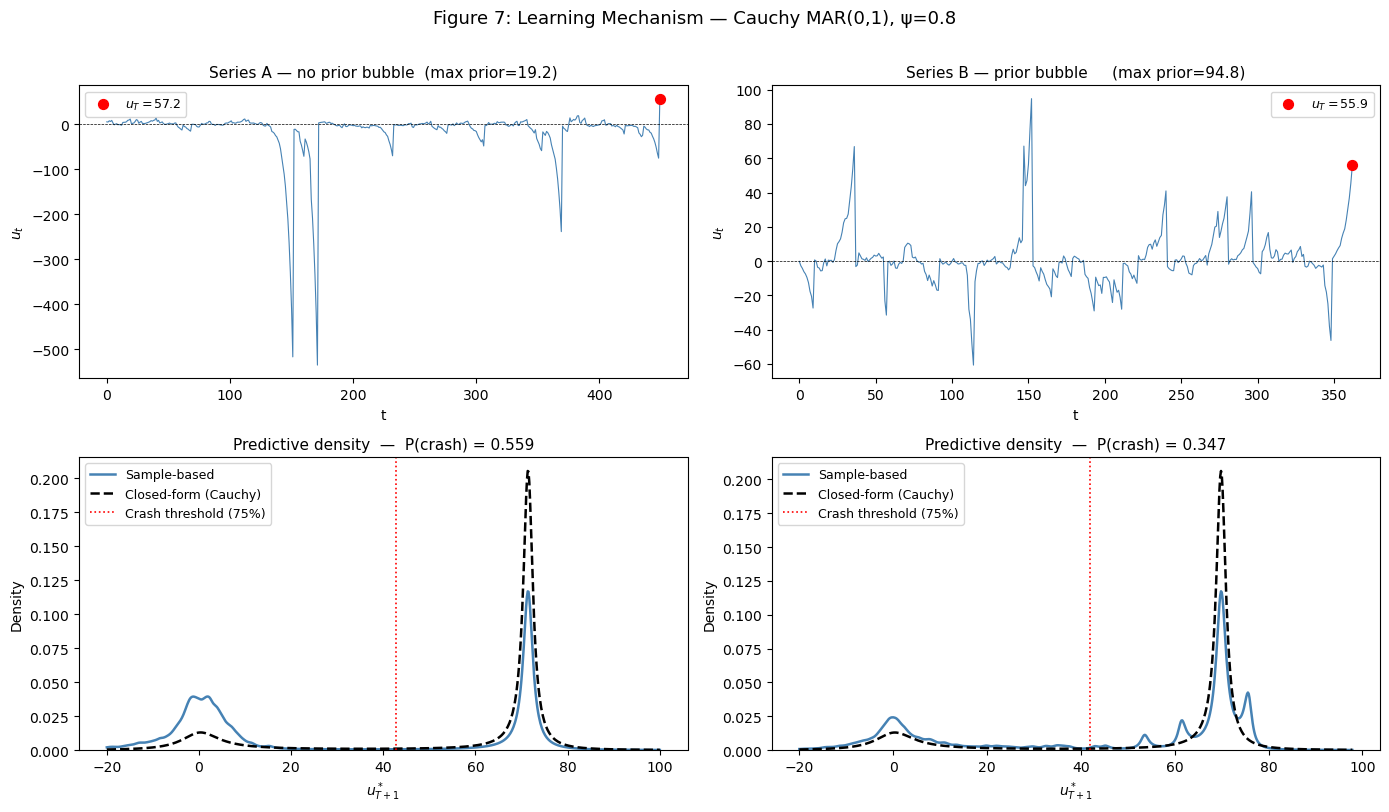

Saved fig07_learning_mechanism.png


In [8]:
# Series A (seed=532): no prior bubble — max prior = 19.2
# Series B (seed=0):   prior bubble   — max prior = 94.8
# Both have u_T ≈ 55–57 (near Q(0.975) = 63.5)

psi, gamma = 0.8, 1.0

def get_series(seed, T=500, u_lo=55, u_hi=75):
    np.random.seed(seed)
    u = simulate_mar01(T=T, psi=psi, df=1.0, scale=gamma)
    cands = np.where((u >= u_lo) & (u <= u_hi))[0]
    valid = cands[cands >= 50]
    idx   = valid[-1]
    return u[:idx+1], float(u[idx])

u_a, uT_a = get_series(532)
u_b, uT_b = get_series(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for col, (u_seg, u_T, label) in enumerate([
        (u_a, uT_a, f"Series A — no prior bubble  (max prior={u_a[:-1].max():.1f})"),
        (u_b, uT_b, f"Series B — prior bubble     (max prior={u_b[:-1].max():.1f})")
    ]):
        prior = u_seg[:-1]
        grid  = np.linspace(-20, u_T / psi * 1.4, 700)

        p_s  = sample_crash_probability(u_T, prior, psi, 1.0, gamma, 0.75 * u_T)
        d_s  = sample_predictive_density(u_T, prior, psi, 1.0, gamma, grid)
        d_c  = cauchy_predictive_density(u_T, psi, gamma, grid)
        d_c /= np.trapezoid(d_c, grid)

        # Trajectory
        ax = axes[0, col]
        ax.plot(u_seg, color='steelblue', lw=0.8)
        ax.axhline(0, color='k', lw=0.5, ls='--')
        ax.scatter([len(u_seg)-1], [u_T], color='red', s=50, zorder=5,
                   label=f"$u_T={u_T:.1f}$")
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("t"); ax.set_ylabel("$u_t$"); ax.legend(fontsize=9)

        # Density
        ax = axes[1, col]
        ax.plot(grid, d_s, color='steelblue', lw=1.8, label='Sample-based')
        ax.plot(grid, d_c, color='black',     lw=1.8, ls='--', label='Closed-form (Cauchy)')
        ax.axvline(0.75 * u_T, color='red', lw=1.2, ls=':', label='Crash threshold (75%)')
        ax.set_title(f"Predictive density  —  P(crash) = {p_s:.3f}", fontsize=11)
        ax.set_xlabel("$u^*_{{T+1}}$"); ax.set_ylabel("Density")
        ax.legend(fontsize=9); ax.set_ylim(bottom=0)

plt.suptitle("Figure 7: Learning Mechanism — Cauchy MAR(0,1), ψ=0.8", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig07_learning_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig07_learning_mechanism.png")

## Figure 8 — Distribution of sample-based crash probabilities
Histograms of P(crash) across 100 Monte Carlo replications for ψ ∈ {0.2, 0.5, 0.8} and T ∈ {500, 1000}.
Red dashed line = theoretical Cauchy probability.

  ψ=0.2, T=500...
  ψ=0.2, T=1000...
  ψ=0.5, T=500...
  ψ=0.5, T=1000...
  ψ=0.8, T=500...
  ψ=0.8, T=1000...


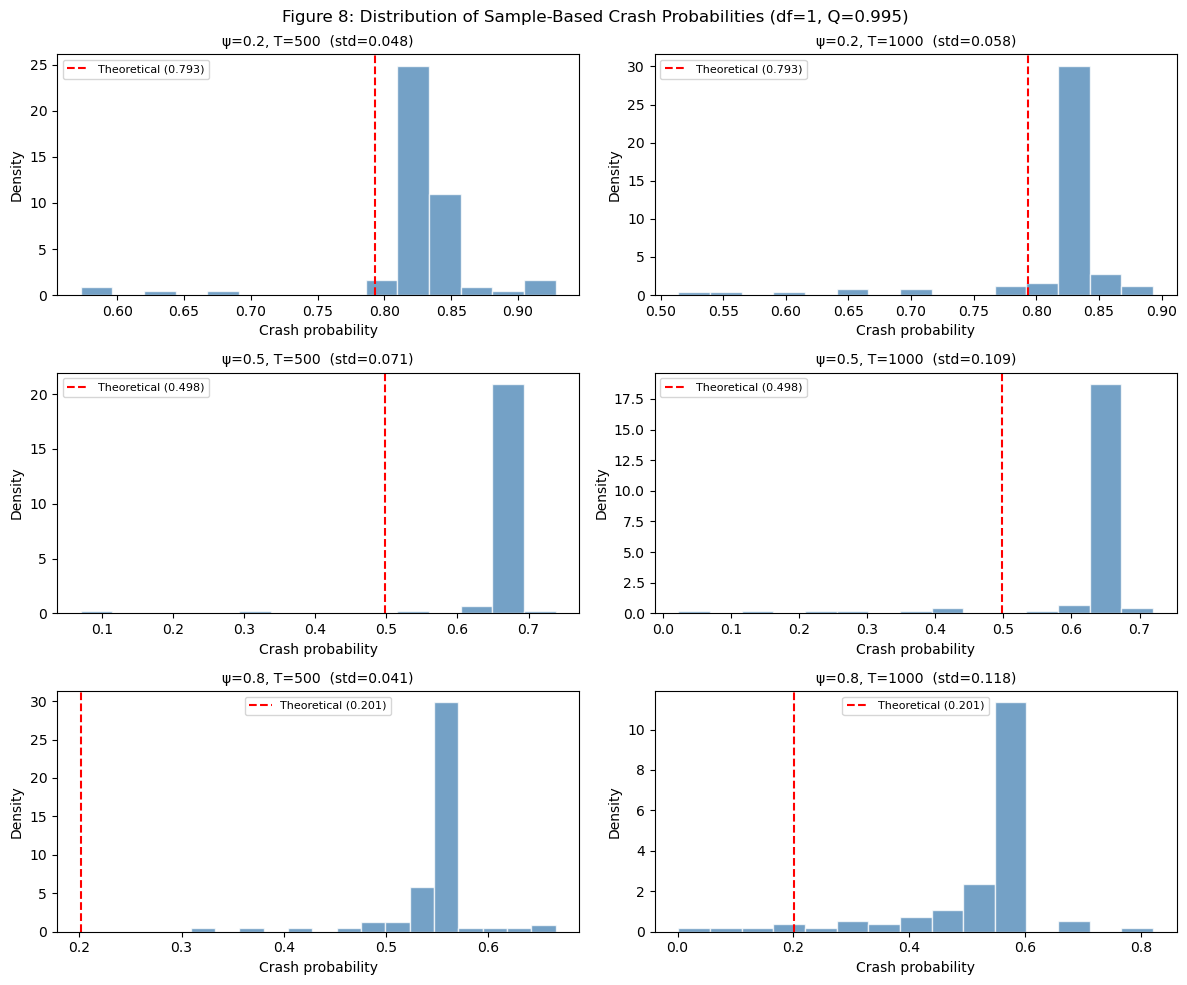

Saved fig08_sample_distribution.png


In [ ]:
def run_mc_probs(psi, sample_size, n_reps=100, quantile=0.995, crash_pct=0.25):
    probs = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for rep in range(n_reps):
            np.random.seed(rep * 1000 + int(psi * 10) * 100 + sample_size)
            u = simulate_mar01(T=sample_size, psi=psi, df=1.0, scale=1.0)
            idx, u_T = find_bubble_point(u, quantile)
            if u_T is None:
                continue
            threshold = (1 - crash_pct) * u_T
            p = sample_crash_probability(u_T, u[:idx], psi, 1.0, 1.0, threshold)
            probs.append(p)
    return np.array(probs)

psi_vals = [0.2, 0.5, 0.8]
sizes    = [500, 1000]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for row, psi in enumerate(psi_vals):
    theory = cauchy_theoretical(psi)
    for col, T in enumerate(sizes):
        print(f"  ψ={psi}, T={T}...")
        probs = run_mc_probs(psi, T, n_reps=100)
        ax = axes[row, col]
        ax.hist(probs, bins=15, color='steelblue', edgecolor='white', alpha=0.75, density=True)
        ax.axvline(theory, color='red', lw=1.5, ls='--',
                   label=f'Theoretical ({theory:.3f})')
        ax.set_title(f"ψ={psi}, T={T}  (std={probs.std():.3f})", fontsize=10)
        ax.set_xlabel("Crash probability"); ax.set_ylabel("Density")
        ax.legend(fontsize=8)

plt.suptitle("Figure 8: Distribution of Sample-Based Crash Probabilities (df=1, Q=0.995)",
             fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig08_sample_distribution.png', dpi=150)
plt.show()
print("Saved fig08_sample_distribution.png")

## Figure 5 — Empirical distribution of crash probabilities
Estimated by running `crash_probability()` at u_T = Q(0.995) across 1,000 iterations
for N ∈ {10,000 / 100,000 / 1,000,000}.

**⚠️ Computationally expensive (~1–2 hours for n_iterations=1000, N=1M).
Run this cell manually when time allows.**

u_T = 318.3,  threshold = 238.7
N=    10,000  mean=0.3673  std=0.2384
N=   100,000  mean=0.2188  std=0.0676
N= 1,000,000  mean=0.2018  std=0.0184


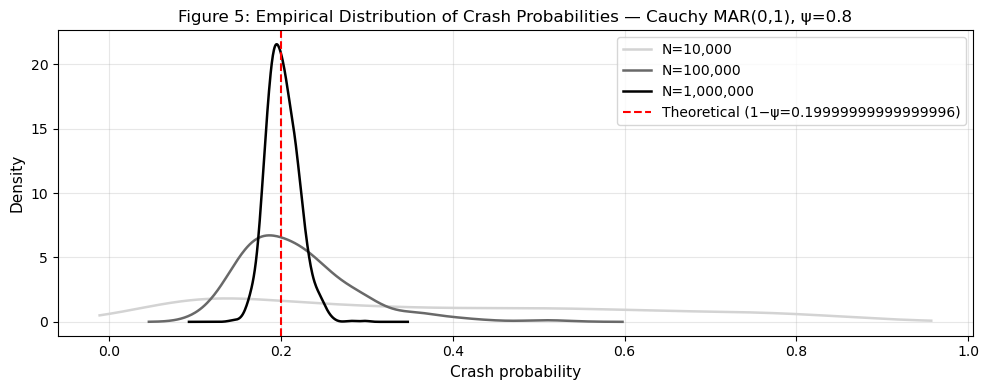

Saved fig05_crash_prob_distribution.png


In [10]:
from scipy.stats import gaussian_kde

psi, gamma   = 0.8, 1.0
marginal_scale = gamma / (1 - psi)
u_T          = cauchy.ppf(0.995, scale=marginal_scale)  # ≈ 318.3
threshold    = 0.75 * u_T
n_iterations = 1000   # reduce to 200 for a quick test
N_values     = [10_000, 100_000, 1_000_000]
colors       = ['lightgrey', 'dimgrey', 'black']
theoretical  = 1 - psi   # = 0.2

print(f"u_T = {u_T:.1f},  threshold = {threshold:.1f}")
all_probs = {}

for N in N_values:
    probs = []
    for i in range(n_iterations):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            p = crash_probability(u_T=u_T, psi=psi, df=1.0, scale=gamma,
                                  threshold=threshold, N=N, M=100)
        probs.append(p)
    all_probs[N] = np.array(probs)
    print(f"N={N:>10,}  mean={np.mean(probs):.4f}  std={np.std(probs):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
for N, color in zip(N_values, colors):
    probs = all_probs[N]
    kde   = gaussian_kde(probs, bw_method=0.3)
    xs    = np.linspace(probs.min() - 0.05, probs.max() + 0.05, 400)
    ax.plot(xs, kde(xs), color=color, lw=1.8, label=f"N={N:,}")

ax.axvline(theoretical, color='red', lw=1.5, ls='--', label=f'Theoretical (1−ψ={theoretical})')
ax.set_xlabel("Crash probability", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Figure 5: Empirical Distribution of Crash Probabilities — Cauchy MAR(0,1), ψ=0.8",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/paper/fig05_crash_prob_distribution.png', dpi=150)
plt.show()
print("Saved fig05_crash_prob_distribution.png")